In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [4]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

In [8]:
feature_names = iris.feature_names
target_names = iris.target_names

print(feature_names)
print(target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [15]:
df = pd.DataFrame(X,columns = feature_names)
df['target'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [16]:
df.shape

(150, 5)

In [18]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [19]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [20]:
# It is unnecessary but I am doing this for educational consistency!!

X = df.drop('target', axis = 1)
y = df['target']  

In [21]:
# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

In [23]:
# Creating the Decision Tree model
model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

In [24]:
# Train the model
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [25]:
# Make the predictions
y_pred = model.predict(X_test)

In [35]:
# Evaluate the model
accuracy = accuracy_score(y_test,y_pred)
print('Accuracy :', round(accuracy,2))

Accuracy : 0.97


In [39]:
# Verifying with the confusion matrix
print('Confusion Matrix :' '\n' ,confusion_matrix(y_test,y_pred))

Confusion Matrix :
 [[10  0  0]
 [ 0  9  0]
 [ 0  1 10]]


In [46]:
# Classification Report
clr = classification_report(y_test, y_pred, target_names = target_names)
print(clr)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      1.00      0.95         9
   virginica       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



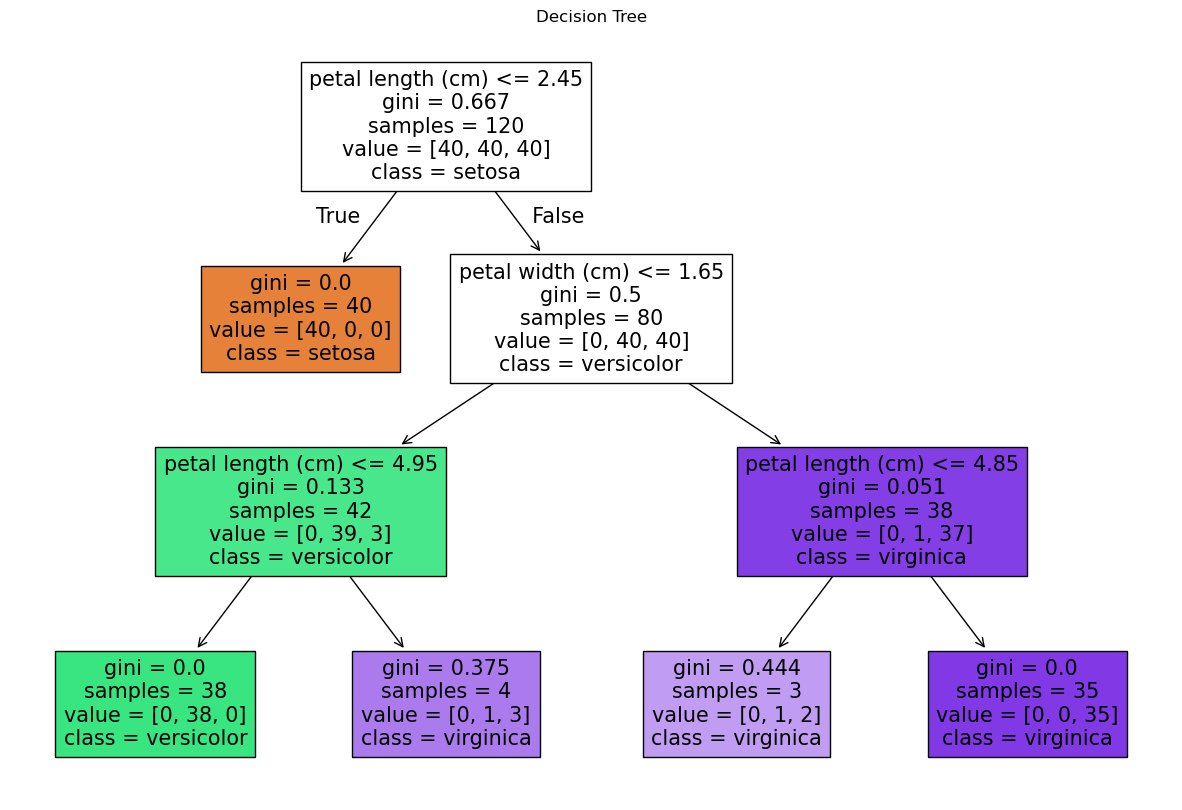

In [47]:
plt.figure(figsize=(15, 10))

plot_tree(
    model,
    feature_names=feature_names,
    class_names=target_names,
    filled=True
)

plt.title("Decision Tree")

plt.show()

In [53]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
feature_importance

,Feature,Importance
2,petal length (cm),0.579077
3,petal width (cm),0.420923
1,sepal width (cm),0.000000
0,sepal length (cm),0.000000


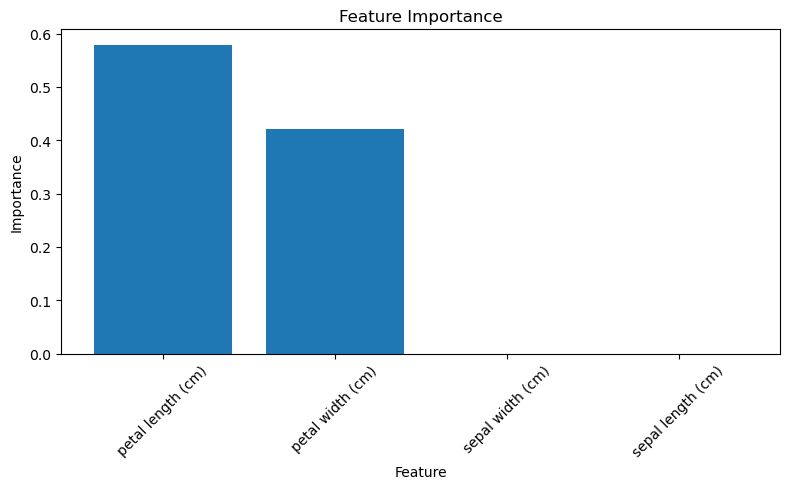

In [55]:
plt.figure(figsize=(8, 5))

plt.bar(feature_importance["Feature"], feature_importance["Importance"])

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [57]:
# Trying out the model with different values of max_depth to prevent Overfitting and Underfitting

depth_values = range(1,11)
results = []

for depth in depth_values:
    model = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
     
    #Train
    model.fit(X_train, y_train)

    #Predict
    y_pred = model.predict(X_test)

    # Evaluating the accuracy score
    accuracy = accuracy_score(y_test, y_pred)

    results.append(accuracy)

In [59]:
# Now, put the results into a dataframe!

results_df = pd.DataFrame({
    'Max_depth': list(depth_values),
    'Accuracy': results
})

results_df

,Max_depth,Accuracy
0,1,0.666667
1,2,0.933333
2,3,0.966667
3,4,0.933333
4,5,0.933333
5,6,0.933333
6,7,0.933333
7,8,0.933333
8,9,0.933333
9,10,0.933333


In [61]:
best_index = results_df["Accuracy"].idxmax()

best_depth = results_df.loc[best_index, "Max_depth"]

best_accuracy = results_df.loc[best_index, "Accuracy"]

print("Best max_depth:", best_depth)
print("Best accuracy :", round(best_accuracy, 2))

Best max_depth: 3
Best accuracy : 0.97


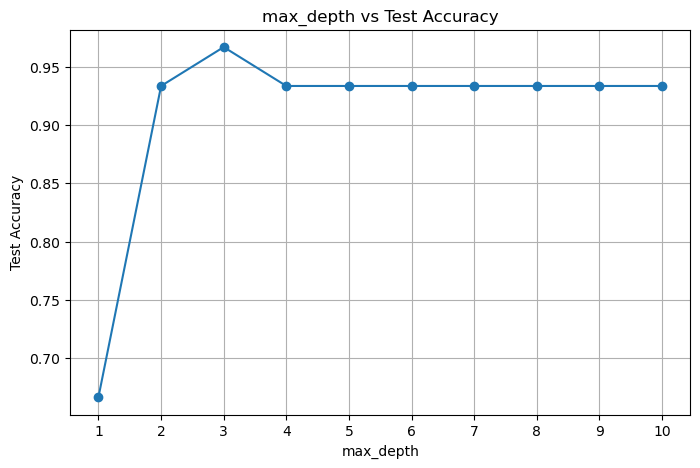

In [63]:
plt.figure(figsize=(8, 5))

plt.plot(depth_values, results, marker="o")

plt.xlabel("max_depth")
plt.ylabel("Test Accuracy")
plt.title("max_depth vs Test Accuracy")

plt.xticks(depth_values)
plt.grid()

plt.show()